Problem Statement and Objective

Task 1: Term Deposit Subscription Prediction
Objective: Predict whether a bank customer will subscribe to a term deposit as a result of a marketing campaign using classification modeling.
Dataset: Bank Marketing Dataset (UCI Machine Learning Repository)

Dataset description and loading

In [1]:
# Import the necessary data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
# CRITICAL: This specific dataset uses semicolons (;) instead of commas to separate columns!
df = pd.read_csv('bank-additional-full.csv', sep=';')

# 2. Display the first 5 rows to confirm it loaded correctly
print("First 5 rows of the dataset:")
display(df.head())

C:\Users\admin\AppData\Local\Temp\ipykernel_25472\1918483485.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


First 5 rows of the dataset:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Data cleaning and preprocessing

In [2]:
# 3. Check data types and look for missing values
print("\n--- Dataset Info ---")
df.info()

# 4. Confirm exact counts of missing values
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# 5. Check the distribution of our Target Variable ('y')
print("\n--- Target Variable Distribution ('y') ---")
print(df['y'].value_counts())
print("\nPercentage distribution:")
print(df['y'].value_counts(normalize=True) * 100)


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf

Exploratory Data Analysis (EDA)

In [3]:
# 1. Drop the 'duration' column to prevent data leakage
df = df.drop(columns=['duration'])

# 2. Encode the target variable 'y' to binary (0 and 1)
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# 3. One-Hot Encode the remaining categorical 'object' columns
# pd.get_dummies automatically finds 'object' columns and creates binary columns for each category.
# drop_first=True drops one category per feature to avoid the "dummy variable trap" (multicollinearity).
df_encoded = pd.get_dummies(df, drop_first=True)

# 4. Display the new dataset shape and the first few rows
print(f"Old dataset shape: {df.shape}")
print(f"New encoded dataset shape: {df_encoded.shape}")
display(df_encoded.head())

Old dataset shape: (41188, 20)
New encoded dataset shape: (41188, 53)


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,True,False,False,False,True,False,False,False,True,False
1,57,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,True,False,False,False,True,False,False,False,True,False
2,37,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,True,False,False,False,True,False,False,False,True,False
3,40,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,True,False,False,False,True,False,False,False,True,False
4,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,True,False,False,False,True,False,False,False,True,False


Model building and evaluation

In [4]:
from sklearn.model_selection import train_test_split

# Separate the features (X) from the target (y)
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

# Split the data (80% training, 20% testing)
# stratify=y ensures the 88/11 imbalance is maintained in both the training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (32950, 52)
Testing features shape: (8238, 52)


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the models
# max_iter=1000 ensures Logistic Regression has enough time to converge
# n_jobs=-1 tells Random Forest to use all your computer's CPU cores for maximum speed
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42)

# 2. Train the models on the training data
print("Training Logistic Regression...")
log_reg.fit(X_train, y_train)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)

print("\nModels trained successfully! ✅")

Training Logistic Regression...


c:\Users\admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Random Forest...

Models trained successfully! ✅


--- Logistic Regression Performance ---
F1-Score (Class 1): 0.4535
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7310
           1       0.35      0.64      0.45       928

    accuracy                           0.83      8238
   macro avg       0.65      0.75      0.67      8238
weighted avg       0.88      0.83      0.85      8238


--- Random Forest Performance ---
F1-Score (Class 1): 0.3836
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7310
           1       0.58      0.29      0.38       928

    accuracy                           0.90      8238
   macro avg       0.75      0.63      0.66      8238
weighted avg       0.88      0.90      0.88      8238



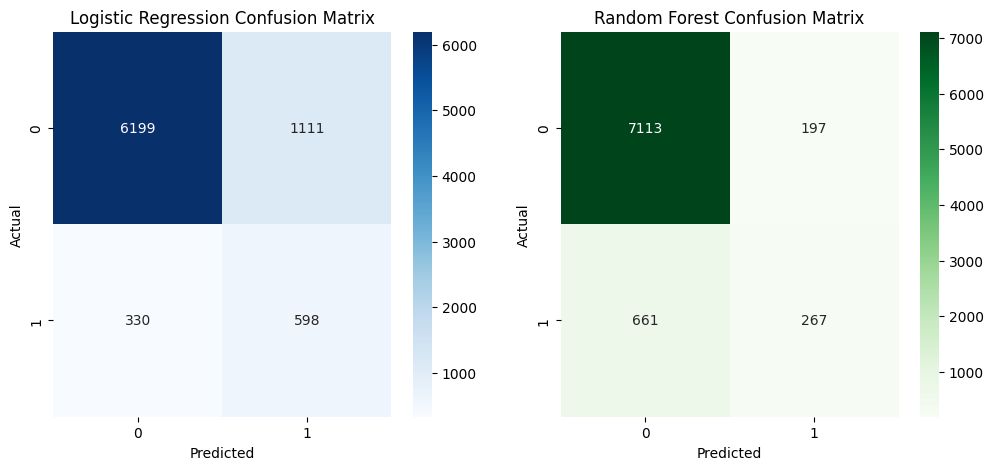

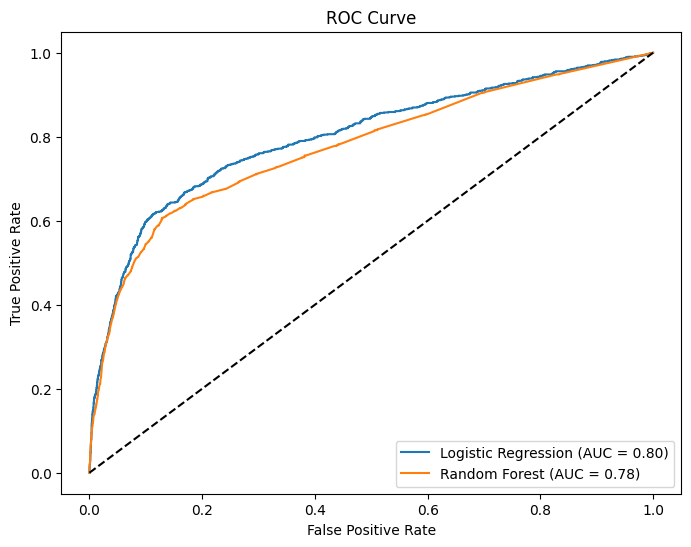

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_curve, auc

# 1. Make predictions on the test data
y_pred_lr = log_reg.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# Get probabilities for the ROC curve
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# 2. Print F1-Scores and Classification Reports
print("--- Logistic Regression Performance ---")
print(f"F1-Score (Class 1): {f1_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

print("\n--- Random Forest Performance ---")
print(f"F1-Score (Class 1): {f1_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

# 3. Plot Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Logistic Regression Confusion Matrix')
ax[0].set_ylabel('Actual')
ax[0].set_xlabel('Predicted')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Random Forest Confusion Matrix')
ax[1].set_ylabel('Actual')
ax[1].set_xlabel('Predicted')
plt.show()

# 4. Plot ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc(fpr_lr, tpr_lr):.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Diagonal guessing line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

Visualizations Through SHAP

--- Explaining 5 Individual Predictions ---

Customer 1 Prediction Explanation:


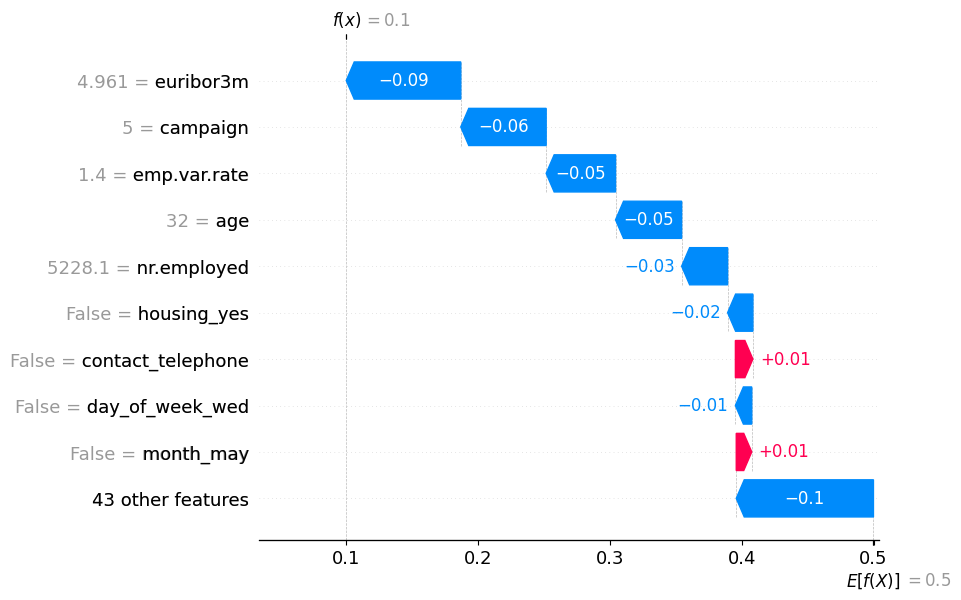


Customer 2 Prediction Explanation:


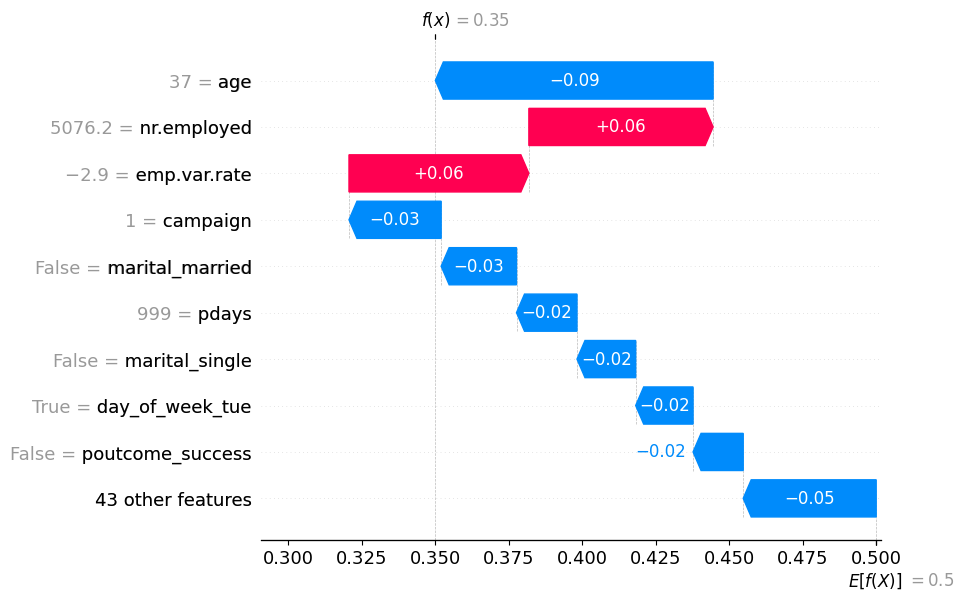


Customer 3 Prediction Explanation:


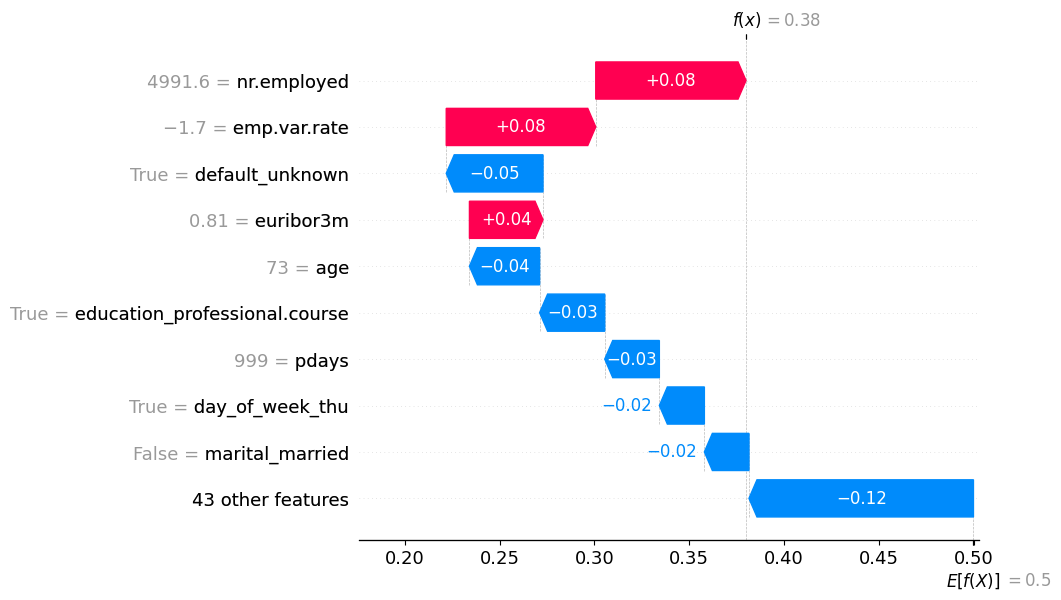


Customer 4 Prediction Explanation:


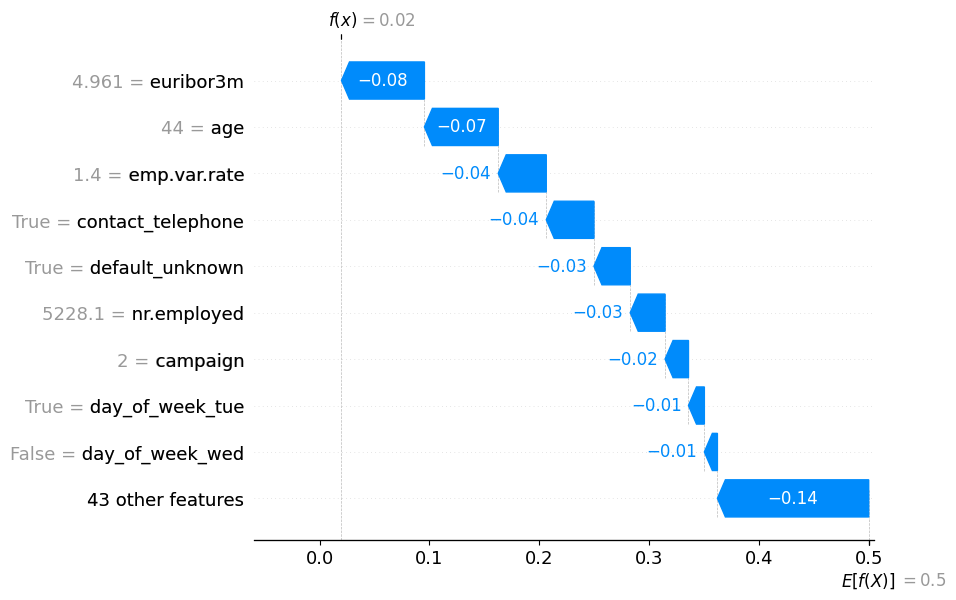


Customer 5 Prediction Explanation:


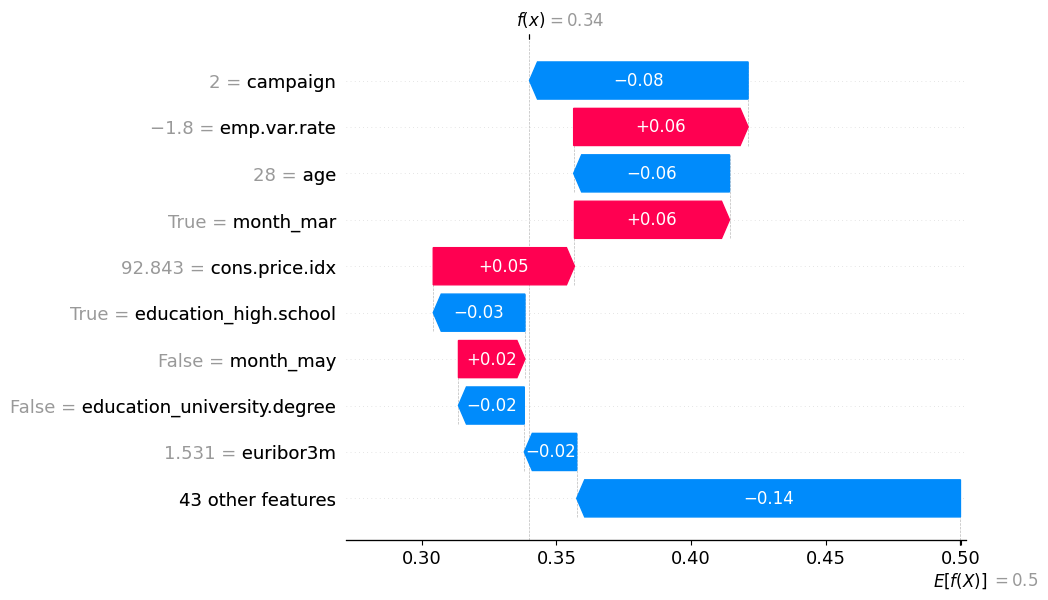

In [7]:
import shap
import matplotlib.pyplot as plt

# 1. Create a TreeExplainer for the Random Forest model
explainer = shap.TreeExplainer(rf_model)

# 2. Select 5 customers from the test set to explain
X_test_5 = X_test.iloc[:5]

# 3. Calculate SHAP values for these 5 customers
# (This computes how much each feature pushed the prediction away from the baseline)
shap_values = explainer(X_test_5)

# For Random Forest, SHAP calculates values for both "No" (Class 0) and "Yes" (Class 1).
# We want to explain why the model thought they would say "Yes", so we select Class 1.
shap_values_class_1 = shap_values[:, :, 1]

# 4. Generate Waterfall plots for the 5 predictions
print("--- Explaining 5 Individual Predictions ---")
for i in range(5):
    print(f"\nCustomer {i+1} Prediction Explanation:")
    # The waterfall plot shows how features pushed the prediction up (red) or down (blue)
    shap.plots.waterfall(shap_values_class_1[i])
    plt.show()

Logistic Regression performed better on the F1-Score because it prioritized recall, making it better for catching potential subscribers.